# Understanding Balanced Functions in Deutsch–Jozsa

A balanced function returns:

* `0` for exactly half of all possible inputs
* `1` for the other half

For `n = 2`, there are:

```text
2^2 = 4
```

possible inputs:

```text
00, 01, 10, 11
```

One example of a balanced function is:

| Input x | f(x) |
| ------- | ---- |
| 00      | 0    |
| 01      | 1    |
| 10      | 1    |
| 11      | 0    |

This function is balanced because:

* two inputs map to `0`
* two inputs map to `1`

---

# Why does Deutsch–Jozsa output a non-zero bitstring for balanced functions?

The Deutsch–Jozsa algorithm works using quantum interference.

After the first Hadamard layer, the input qubits are placed into a superposition of all possible inputs.

The oracle then applies phase changes based on the function values:

* inputs where `f(x)=0` keep the same phase
* inputs where `f(x)=1` receive a phase flip

For a constant function:

* all amplitudes receive the same phase behavior
* the amplitudes interfere constructively
* they combine back into:

```text
|000...0⟩
```

So measurement always produces all zeros.

For a balanced function:

* some amplitudes get phase flips while others do not
* the phases no longer align perfectly
* destructive interference occurs at `|000...0⟩`

As a result:

* the probability of measuring all zeros becomes zero
* the circuit produces a non-zero bitstring instead

This interference behavior is what allows the Deutsch–Jozsa algorithm to distinguish constant and balanced functions using only one oracle query.


In [1]:
import sys
import os

# Add the parent directory to Python's search path
sys.path.append(os.path.abspath('..'))

from qiskit_aer import AerSimulator
from qiskit import transpile
from qiskit.visualization import plot_histogram

from quantum_qr.dj import (
    dj_circuit,
    balanced_oracle,
    oracle_from_secret_string,
)

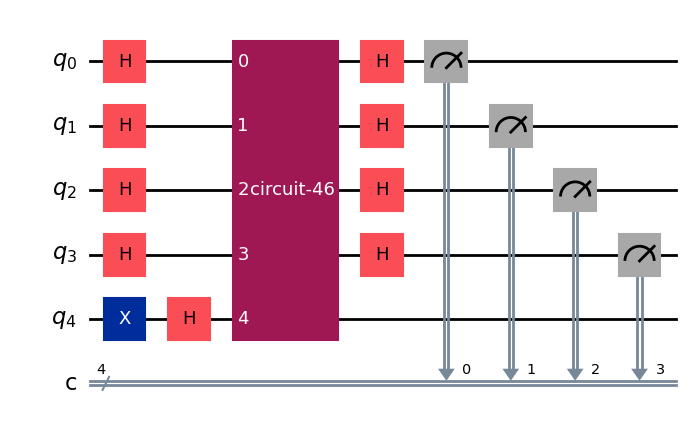

In [3]:
simulator = AerSimulator()

n = 4

oracle_balanced = balanced_oracle(n)

dj_balanced = dj_circuit(oracle_balanced, n)

dj_balanced.draw('mpl')

In [4]:
compiled = transpile(dj_balanced, simulator)

job = simulator.run(compiled, shots=1024)

result = job.result()

counts = result.get_counts()

print(counts)

{'1111': 1024}


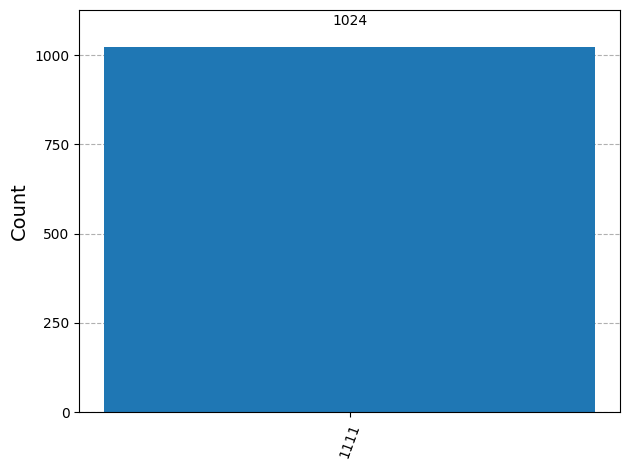

In [5]:
plot_histogram(counts)

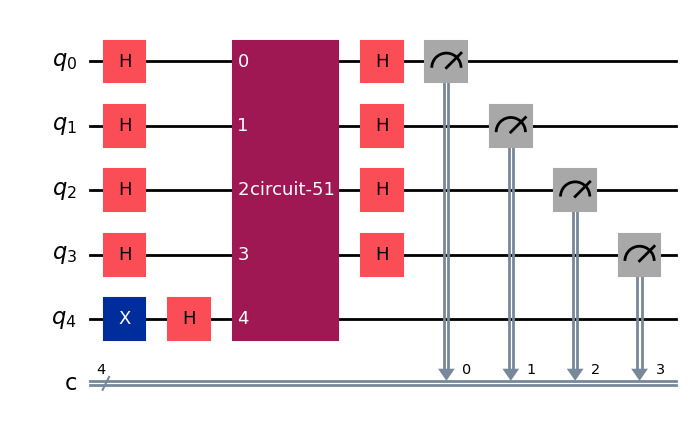

In [7]:
secret = "1010"

oracle_secret = oracle_from_secret_string(secret)

dj_secret = dj_circuit(oracle_secret, len(secret))

dj_secret.draw('mpl')

In [8]:
compiled_secret = transpile(dj_secret, simulator)

job_secret = simulator.run(compiled_secret, shots=1024)

result_secret = job_secret.result()

counts_secret = result_secret.get_counts()

print(counts_secret)

{'0101': 1024}


In [10]:
secret_zero = "0000"

oracle_zero = oracle_from_secret_string(secret_zero)

dj_zero = dj_circuit(oracle_zero, 4)

compiled_zero = transpile(dj_zero, simulator)

job_zero = simulator.run(compiled_zero, shots=1024)

result_zero = job_zero.result()

counts_zero = result_zero.get_counts()

print(counts_zero)

{'0000': 1024}


# Balanced Functions and Secret Recovery

Today I tested the Deutsch–Jozsa algorithm using balanced oracles and secret-string oracles.

---

# 1. Balanced Oracle

I first tested:

```python
balanced_oracle(4)
```

The measured result was:

```text
1111
```

with 100% probability.

Unlike constant functions, which always produce:

```text
0000
```

balanced functions create destructive interference at the all-zero state. This prevents the amplitudes from combining back into `|0000⟩`, so the circuit produces a non-zero bitstring instead.

---

# 2. Secret String Oracle

I then tested:

```python
oracle_from_secret("1010")
```

The measured result was:

```text
1010
```

(with possible reversal depending on Qiskit's bit ordering).

This was the key observation:

the circuit did not merely detect that the function was balanced — it actually recovered the hidden secret string in a single oracle query.

Mathematically, the oracle computes:

```text
f(x) = s · x (mod 2)
```

where:

* `s` is the hidden secret string
* `x` is the input bitstring

The phase kickback from the oracle encodes the secret into the amplitudes, and the final Hadamard transform converts this phase information back into measurable computational-basis information.

---

# 3. Secret = "0000"

Finally, I tested:

```python
oracle_from_secret("0000")
```

The output returned to:

```text
0000
```

because the all-zero secret corresponds to a constant function.

---

# Important Insight

The Deutsch–Jozsa circuit and the Bernstein–Vazirani circuit are actually the same circuit structure.

* Deutsch–Jozsa asks:
  "Is the function constant or balanced?"

* Bernstein–Vazirani asks:
  "What hidden string defines the function?"

This project uses the secret-recovery interpretation because it maps naturally to QR-code verification:

* authentic QR → expected secret recovered
* tampered QR → different secret recovered


### Generate and read QR Code

In [5]:
import os
from quantum_qr.qr_io import make_qr_code, read_qr_code

qr_path = "./data/test_qr.png"
os.makedirs(os.path.dirname(qr_path), exist_ok=True)

# Create QR image
make_qr_code("hello quantum world", qr_path)

# Decode QR image
decoded = read_qr_code(qr_path)

print(decoded)

hello quantum world
